In [1]:
from langfuse import get_client
from langfuse.langchain import CallbackHandler
# Initialize Langfuse client
langfuse = get_client()
# Initialize Langfuse CallbackHandler for Langchain (tracing)
langfuse_handler = CallbackHandler()

In [2]:
# Core LLM + tool + graph imports
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.tools import tool
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
# In-memory checkpoint store for multi-turn thread conversations
from langgraph.checkpoint.memory import MemorySaver


# Standard library typing/date utilities
from datetime import datetime
from typing import List, Optional, Annotated
from typing_extensions import TypedDict


In [3]:
# Initialize the base chat model and attach tracing callbacks
LLM = ChatNVIDIA(
    model="openai/gpt-oss-120b",
    # model="meta/llama-3.1-70b-instruct",
    temperature=0,
    callbacks=[langfuse_handler],
)

In [4]:
search_tool = GoogleSerperAPIWrapper()

@tool
def search(query: str) -> str:
    """Search the internet for information about a query and return the results.
    """
    return search_tool.run(query)

In [5]:
tools = [search]

llm_with_tools = LLM.bind_tools(tools)

In [6]:
# defining the state of the graph
class State(TypedDict):
    """State of the graph."""
    messages: Annotated[list, add_messages]  # List of messages in the conversation reduser this apped the messages to the state

In [17]:


# defining a node
def chatbot(state: State):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}   

In [18]:
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(
    name="tool_node",
    tools=tools)

graph_builder.add_node(
    "tools",
    tool_node)
# memory saver to store the state of the conversation in memory for multi-turn conversations
memory = MemorySaver()

# Route chatbot output to the tool node only when a tool call is present
graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")
graph_builder.set_entry_point("chatbot")

In [19]:
graph = graph_builder.compile(
    checkpointer=memory,
    interrupt_before=["tools"]

)

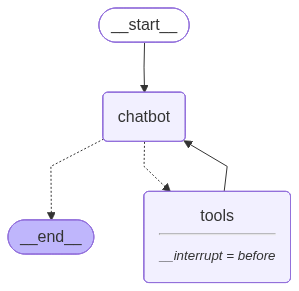

In [20]:
graph

In [21]:
user_input = "Search latest news about Nvidia do a mendatory web search and summarize the findings"
config = {
    "configurable": {"thread_id": "3"}
}

event = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)

for state in event:
    latest_message = state["messages"][-1]
    if getattr(latest_message, "type", None) in {"human", "ai", "tool"}:
        latest_message.pretty_print()


================================ Human Message =================================

Search latest news about Nvidia do a mendatory web search and summarize the findings
================================== Ai Message ==================================
Tool Calls:
  search (chatcmpl-tool-9c13e018af81c01b)
 Call ID: chatcmpl-tool-9c13e018af81c01b
  Args:
    query: Nvidia latest news


In [22]:
snapshot = graph.get_state(config)
snapshot.next

('tools',)

In [23]:
# checking for the paramert to the tool node
latest_message = snapshot.values["messages"][-1]
latest_message.tool_calls


[{'name': 'search',
  'args': {'query': 'Nvidia latest news'},
  'id': 'chatcmpl-tool-9c13e018af81c01b',
  'type': 'tool_call'}]

In [24]:
# I will approve the tool call and let the graph continue executing the tool node and then come back to the chatbot node with the tool response and generate a final response to the user.


event = graph.stream(
    None, # no new input, just continue the execution
    config,
    stream_mode="values",
)

for state in event:
    latest_message = state["messages"][-1]
    if getattr(latest_message, "type", None) in {"human", "ai", "tool"}:
        latest_message.pretty_print()


================================== Ai Message ==================================
Tool Calls:
  search (chatcmpl-tool-9c13e018af81c01b)
 Call ID: chatcmpl-tool-9c13e018af81c01b
  Args:
    query: Nvidia latest news
================================= Tool Message =================================
Name: search

Latest News · No Need for Space Gear — Capcom's 'PRAGMATA' Joins GeForce NOW on Launch Day · Rethinking AI TCO: Why Cost per Token Is the Only Metric That Matters. NEWS_HEADLINES NVIDIA is actively expanding its influence in AI and quantum computing, with recent developments including a potential acquisition of Dell and ... NVIDIA Launches Ising, the World's First Open AI Models to Accelerate the Path to Useful Quantum Computers. Latest On NVIDIA Corp ; Nvidia is the answer to so many of the problems that these big companies have, says Jim Cramer CNBC Video 6 Hours Ago ; Lightning Round: ... ... latest stock market news and analysis. From market futures to live price updates CNBC is

In [25]:

event = graph.stream(
    None, # no new input, just continue the execution
    config,
    stream_mode="values",
)

for state in event:
    latest_message = state["messages"][-1]
    if getattr(latest_message, "type", None) in {"human", "ai", "tool"}:
        latest_message.pretty_print()


================================== Ai Message ==================================
Tool Calls:
  search (chatcmpl-tool-a7f38e2ec630df9e)
 Call ID: chatcmpl-tool-a7f38e2ec630df9e
  Args:
    query: Nvidia news April 2026
================================= Tool Message =================================
Name: search

Nvidia stock is on a 10-day winning streak and up 18% over that stretch. Published Tue, Apr 14 20262:22 PM EDT Updated Tue, Apr 14 20265 ... Nvidia stock is back at the 200 price level after more than five months. Shares are in a base with a buy point of 212.19. NVIDIA will pay its next quarterly cash dividend of $0.01 per share on April 1, 2026, to all shareholders of record on March 11, 2026. Q4 Fiscal ... ... April 29, 2026. What these companies say about CapEx guidance and their AI strategies will have an important impact on NVIDIA stock moving ... This market will resolve to "Yes" if the official closing price for NVIDIA (NVDA) on the final trading day of April 2026 is high

# Let try the Human In Loop by changing the parameter of the tool calls

In [26]:
user_input = "Search latest news about Nvidia"
config = {
    "configurable": {"thread_id": "10"}
}

event = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)

for state in event:
    latest_message = state["messages"][-1]
    if getattr(latest_message, "type", None) in {"human", "ai", "tool"}:
        latest_message.pretty_print()


================================ Human Message =================================

Search latest news about Nvidia
================================== Ai Message ==================================
Tool Calls:
  search (chatcmpl-tool-af12adf81ab6dc50)
 Call ID: chatcmpl-tool-af12adf81ab6dc50
  Args:
    query: latest news Nvidia


In [27]:
snapshot = graph.get_state(config)
print(snapshot.next)

('tools',)


In [28]:
latest_message = snapshot.values["messages"][-1]
print("Original tool call parameters: ", latest_message.tool_calls)
print("Original tools Call message id: ", latest_message.id)

Original tool call parameters:  [{'name': 'search', 'args': {'query': 'latest news Nvidia'}, 'id': 'chatcmpl-tool-af12adf81ab6dc50', 'type': 'tool_call'}]
Original tools Call message id:  lc_run--019d9f81-13c1-7743-a063-f60d6dd6feaf-0


### Lets modify the tool calls parmetrs

In [29]:
from langchain_core.messages import AIMessage 

# AIMessage is immutable, so we need to create a new message with the same content and the same id but with the tool call parameters modified to include a flag that the tool call is approved by the human in the loop

New_tool_calls = latest_message.tool_calls[0].copy()
New_tool_calls["args"]["query"] = "Meta latest news"

new_message = AIMessage(
    content=latest_message.content,
    tool_calls=[New_tool_calls],
    id=latest_message.id # keep the same id to update the existing message in the state with the new tool call parameters
)

# Print the new tools call parameters to verify the changes
print("Modified tool call parameters: ", new_message.tool_calls)

Modified tool call parameters:  [{'name': 'search', 'args': {'query': 'Meta latest news'}, 'id': 'chatcmpl-tool-af12adf81ab6dc50', 'type': 'tool_call'}]


In [30]:
# Now lets update the state with the new message with the modified tool call parameters to continue the execution of the graph with the human in the loop modifications
graph.update_state(config, {"messages": [new_message]})
print("State updated with human in the loop modifications, continuing execution of the graph...")
graph.get_state(config).values["messages"][-1].tool_calls

State updated with human in the loop modifications, continuing execution of the graph...


[{'name': 'search',
  'args': {'query': 'Meta latest news'},
  'id': 'chatcmpl-tool-af12adf81ab6dc50',
  'type': 'tool_call'}]

In [31]:

event = graph.stream(None,
    config,
    stream_mode="values",
)

for state in event:
    latest_message = state["messages"][-1]
    if getattr(latest_message, "type", None) in {"human", "ai", "tool"}:
        latest_message.pretty_print()


================================== Ai Message ==================================
Tool Calls:
  search (chatcmpl-tool-af12adf81ab6dc50)
 Call ID: chatcmpl-tool-af12adf81ab6dc50
  Args:
    query: Meta latest news
================================= Tool Message =================================
Name: search

Recent News · WhatsApp Adds New Features to Simplify Storage, Switch Accounts, and More · Meta Partners With Arm to Develop New Class of Data Center Silicon. News headlines Meta is set to initiate a new round of layoffs affecting about 8,000 jobs, or 10% of its workforce, starting May 20. This restructuring aligns ... April 13, 2026. Meta to Announce First Quarter 2026 Results ; February 25, 2026. Meta to Participate in the Morgan Stanley Technology, Media & Telecom Conference. Meta Platforms Inc META:NASDAQ ; Close. 688.55 quote price arrow up +11.68 (+1.73%) ; Volume. 13,919,927 ; 52 week range. 479.80 - 796.25. See the latest on Meta. From breaking news to in-depth reporting, Bloom